# <center>增广神经微分方程：二分类问题</center>

## 1. 问题描述

给定二维数据点 $\{ X = (X_0, X_1) \}_{x\in\Omega}$ 及其所对应的标签 $y \in \{0, 1\}$，训练一个神经微分方程实现二分类任务。由于神经微分方程无法改变数据点本身的拓扑结构（即 $\mathbf{x} (0) \to \mathbf{x} (1)$ 的映射是一个微分同胚），因此在

- Concentric Circles 数据集

的二分类任务上表现不佳。事实上，可理论证明神经微分方程仅能对输入空间做连续的变换，无法撕裂产生新的拓扑结构。

#### 1-1. 建立神经微分方程模型

为了解决上述问题，首先将数据点作为初始值并添加升维变量 $\mathbf{a}(t)$，然后再通过神经微分方程进行前向演化

$$
\mathbf{x} (0) = \begin{pmatrix} X \\ \mathbf{a}(0)=0 \end{pmatrix}; 
\ \
\frac{d \mathbf{x} (t)}{dt} = f_{\textnormal{NN}}( \mathbf{x} (t), t; \theta )
\ \ \
\textnormal{for}
\ \ \
0 < t\leq 1,
$$
其中方程的右端项用神经网络进行参数化，$\mathbf{x}(t)\in\mathbb{R}^{3\times 1}$ 相较于标准的神经微分方程维数增加，且此时可训练参数 $\theta$ 与时间变量 $t$ 无关。

#### 1-2. 损失函数及其优化问题

针对单个数据点 $\mathbf{x} (0) = X$，在得到 $t=1$ 时刻的演化数据 $\mathbf{x} (1)$ 后，首先需要通过一个全连接层将其进行降维操作
$$
\hat{\mathbf{x}} (1) = W \mathbf{x} (1) + b := g(\mathbf{x} (1)) \in \mathbb{R}^{2\times 1}
$$

通过 softmax 函数将结果转化为的分类概率
$$
\sigma( \hat{\mathbf{x}} (1) ) = \left( \frac{ e^{\hat{\mathbf{x}}_1(1)} }{ e^{\hat{\mathbf{x}}_1(1)} + e^{\hat{\mathbf{x}}_2(1)} }，  \frac{ e^{\hat{\mathbf{x}}_2(1)} }{ e^{\hat{\mathbf{x}}_1(1)} + e^{\hat{\mathbf{x}}_2(1)} } \right) 
$$
接下来便可在交叉熵（cross entropy）的度量下与真实分类 $y\in\{0, 1\}$ 进行比较
$$
\varphi( \hat{\mathbf{x}} (1) ) = -  \left[ y \log^{\sigma_0( \hat{\mathbf{x}} (1) )} + (1-y) \log^{\sigma_1( \hat{\mathbf{x}} (1) )} \right] := \textnormal{CrossEntropyLoss}( \hat{\mathbf{x}} (1), y).
$$
因此，神经网络可训练参数所对应的优化问题为
\begin{equation*}
	\begin{array}{cl}
		\displaystyle  \min_\theta & \displaystyle \mathbb{E}_{X\in\Omega} \big[ \varphi \circ g(\mathbf{x} (1) ) \big] \\
		\textnormal{s.t.} & \displaystyle  \mathbf{x} (0) = \begin{pmatrix} X \\ \mathbf{a}(0) \end{pmatrix}; \ \
\frac{d \mathbf{x} (t)}{dt} = f_{\textnormal{NN}}( \mathbf{x} (t), t; \theta )\ \ \
\textnormal{for}
\ \ \
0 < t\leq 1.
	\end{array}
\end{equation*}

#### 1-3. 基于伴随方程方法求解

通过变分原理（Calculus of Variations）来求解上述最优控制问题，特别的，torchdiffeq 库中的 odeint 函数巧妙地封装了整个过程。

## 2. 编程求解（Concentric-Circles 数据集）

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader
from IPython.display import display_html, HTML # for animation

import matplotlib.pyplot as plt

# generate sample points and their labels
from Dataset.Generate_Dataset import ConcentricCirclesDataset
import Dataset.Visualize_Dataset_Binary_Classification as Visualization

# construct neural ODE (require torchdiffeq)
try:
    import torchdiffeq
except ModuleNotFoundError:
    !pip install --quiet torchdiffeq
    import torchdiffeq
from Models.Neural_ODE import NODE, ZeroAugmenter, Augmented_NODE, NODE_Trainer

# use PyTorch Lightning to simplify coding
try:
    import pytorch_lightning as pl
except ModuleNotFoundError:
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl   

# for reproducibility
pl.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import warnings
warnings.filterwarnings("ignore")  # ignore warnings for concise

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Seed set to 42


Device: cpu


### 2-1. 创建训练与测试数据集

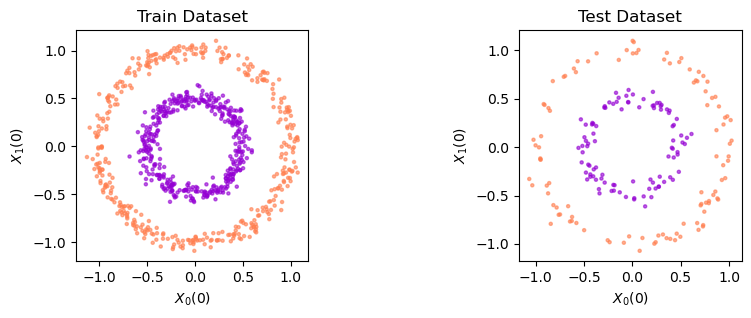

In [2]:
datasize_train = 800
batchsize_train = 800
datasize_test = 200

# create training and testing datasets   z
dataset_full = ConcentricCirclesDataset(datasize_train + datasize_test, noise_std=5e-2)
dataset_train, dataset_test = random_split(dataset_full, [datasize_train, datasize_test])

# visualize training and testing datasets
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3)) 
Visualization.plot_binary_classification_dataset(*dataset_train[:], title='Train Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax0)  
Visualization.plot_binary_classification_dataset(*dataset_test[:], title='Test Dataset', x_label='$X_0(0)$', y_label='$X_1(0)$', ax=ax1) 
plt.subplots_adjust(wspace=0.3) 

# define dataloader
dataloader_train = DataLoader(dataset_train, batch_size=batchsize_train, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=len(dataset_test), shuffle=False)

In [3]:
# print datasets if necessary
#Visualization.print_train_test_dataloader(dataloader_train, dataloader_test) 

### 2-2. 建立并训练神经微分方程

### 2-3. 展示数据在神经微分方程中的流动

In [6]:
# generate trajectories of augmented sample points
@torch.no_grad()
def run_inference_augmentation(trainer, data_loader, time_span):
    trajectories = []
    classes = []
    trainer = trainer.to(device)
    time_span = torch.from_numpy(time_span).to(device)
    for data, target in data_loader:
        data = data.to(device)
        traj = trainer.inference_augmentation(data, time_span).cpu().numpy()
        trajectories.append(traj)
        classes.extend(target.numpy())
    trajectories = np.concatenate(trajectories, 1)
    return trajectories, classes

num_timesteps = 100
time_span = np.linspace(0.0, 1.0, num_timesteps)
trajectories_augmentation, classes = run_inference_augmentation(model_trainer, dataloader_train, time_span)
colors = ['coral', 'darkviolet']
class_colors = [colors[ci] for ci in classes]

anim_augmentation = Visualization.plot_augmented_trajectories_animation(time_span, trajectories_augmentation, colors, classes, lim=8.0)

display(HTML(f"""
<div style="
    display: flex;
    gap: 10px;
    align-items: flex-start;
">
    <div style="flex: 1; min-width: 0;">{anim.to_html5_video()}</div>
    <div style="flex: 1; min-width: 0;">{anim_augmentation.to_html5_video()}</div>
</div>
"""))